# Experiment 10: COIL-20 Three-Block Sparse Factorisation

Apply PALM and FISTA-PALM to a three-block sparse factorisation model on COIL-20 images.

**Setup**
- Dataset: COIL-20 object images
- Image size: $32 \times 32$
- Factorisation model: $A \approx XBY^T$
- Ranks: $r_1 = 30$, $r_2 = 20$
- Sparsity:
  - $20\%$ in $X$
  - $40\%$ in $B$
  - $20\%$ in $Y$
- Iterations: $200$

**Goal**

Compare PALM and FISTA-PALM on a three-block nonconvex sparse factorisation problem.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.problems.three_block_factorisation import ThreeBlockFactorisationProblem
from src.solvers.three_block_palm import ThreeBlockPALM
from src.solvers.three_block_fista_palm import ThreeBlockFISTAPALM

from src.utils.data import download_coil20, load_coil_matrix
from src.utils.io import make_fig_path, save_table
from src.utils.plotting import (
    plot_three_block_combined_reconstruction_grid,
    plot_three_block_dataset_comparison,
)

## Load COIL-20 data

Load the COIL-20 images from a local folder and reshape them into a matrix.

In [2]:
np.random.seed(42)

coil_folder = download_coil20(ROOT)

image_size = (32, 32)
max_images = 300

A, image_shape = load_coil_matrix(
    coil_folder,
    image_size=image_size,
    max_images=max_images,
)

m, n = A.shape
m, n

(1024, 300)

## Set up the three-block problem

Use the sparse factorisation model $A \approx XBY^T$.

In [3]:
r1, r2 = 30, 20
gamma = 1.5
max_iter = 200

s_x = int(0.2 * m * r1)
s_b = int(0.4 * r1 * r2)
s_y = int(0.2 * n * r2)

problem = ThreeBlockFactorisationProblem(
    A,
    s_x=s_x,
    s_b=s_b,
    s_y=s_y,
    gamma=gamma,
)

X0 = np.abs(np.random.randn(m, r1))
B0 = np.random.randn(r1, r2)
Y0 = np.abs(np.random.randn(n, r2))

params = {
    "r1": r1,
    "r2": r2,
    "iter": max_iter,
}

## Run PALM and FISTA-PALM

Compare three-block PALM and three-block FISTA-PALM on COIL-20.

In [4]:
solvers = {
    "PALM": ThreeBlockPALM(max_iter=max_iter),
    "FISTA-PALM": ThreeBlockFISTAPALM(max_iter=max_iter),
}

outputs = {}
histories = {}
records = []

for name, solver in solvers.items():
    X, B, Y, hist = solver.solve(
        problem,
        X0.copy(),
        B0.copy(),
        Y0.copy(),
    )

    outputs[name] = (X, B, Y)
    histories[name] = hist

    records.append({
        "Method": name,
        "Final Objective": hist[-1],
        "Iterations": len(hist) - 1,
    })

df = pd.DataFrame(records)

save_table(
    df,
    ROOT,
    "coil_three_block_summary",
    params,
)

df

,Method,Final Objective,Iterations
0,PALM,5900.829346,200
1,FISTA-PALM,2322.988628,200


## COIL-20 reconstructions

Compare reconstructed object images from PALM and FISTA-PALM.

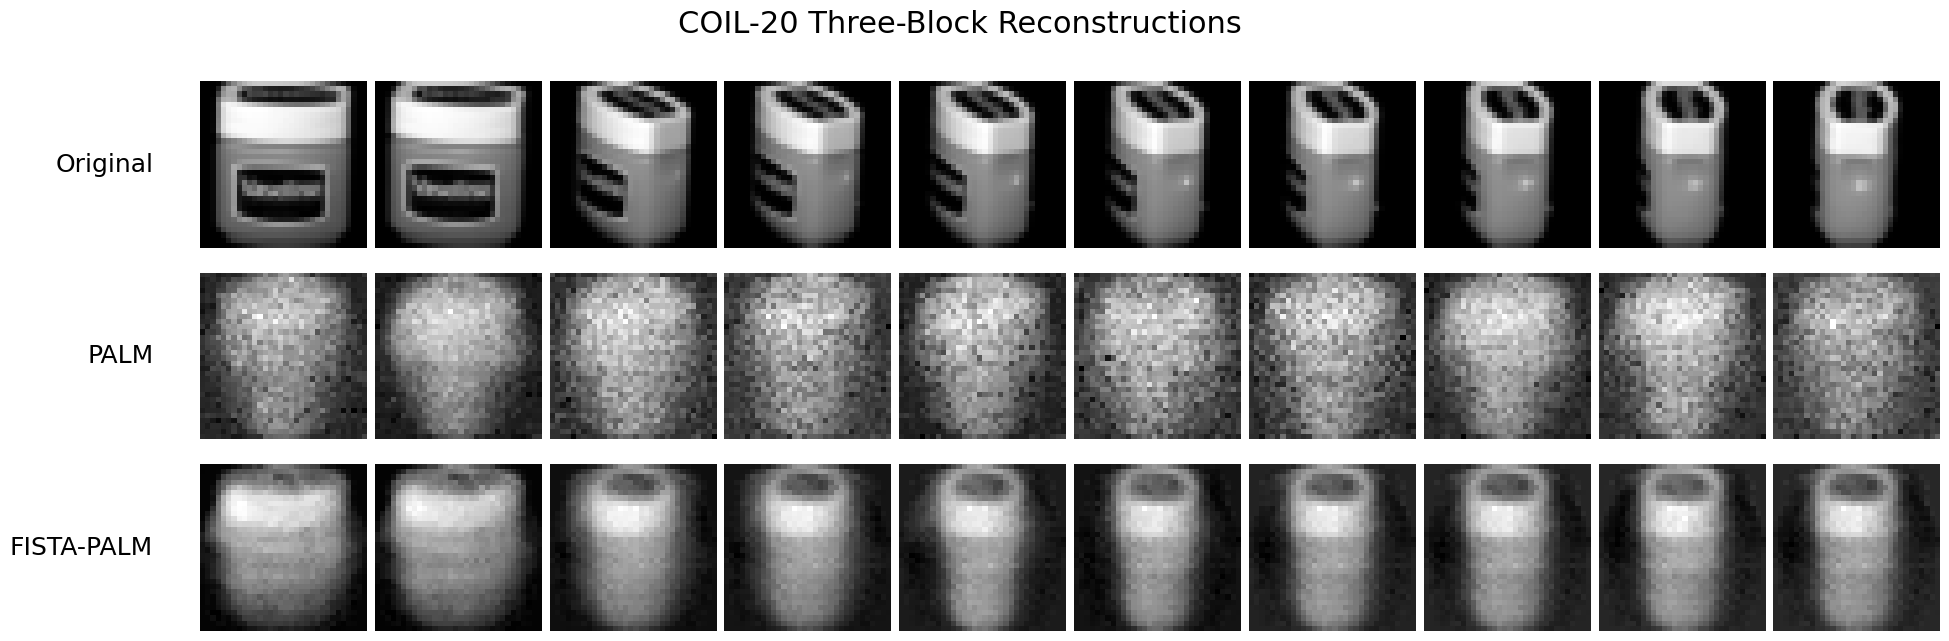

In [ ]:
X_p, B_p, Y_p = outputs["PALM"]
X_f, B_f, Y_f = outputs["FISTA-PALM"]

recon_p = X_p @ B_p @ Y_p.T
recon_f = X_f @ B_f @ Y_f.T

reconstructions = {
    "PALM": recon_p,
    "FISTA-PALM": recon_f,
}

plot_three_block_combined_reconstruction_grid(
    A,
    reconstructions,
    image_shape=image_shape,
    n_images=10,
    row_labels=["Original", "PALM", "FISTA-PALM"],
    title="COIL-20 Three-Block Reconstructions",
    save_path=make_fig_path(ROOT, "coil_three_block_reconstructions", params),
)

## Synthetic comparison

Run the same three-block methods on a synthetic matrix with matching dimensions.

In [6]:
np.random.seed(123)

A_syn = (
    np.random.rand(m, r1)
    @ np.random.rand(r1, r2)
    @ np.random.rand(n, r2).T
)

problem_syn = ThreeBlockFactorisationProblem(
    A_syn,
    s_x=s_x,
    s_b=s_b,
    s_y=s_y,
    gamma=gamma,
)

X0_syn = np.abs(np.random.randn(m, r1))
B0_syn = np.random.randn(r1, r2)
Y0_syn = np.abs(np.random.randn(n, r2))

synthetic_histories = {}

for name, solver in solvers.items():
    _, _, _, hist = solver.solve(
        problem_syn,
        X0_syn.copy(),
        B0_syn.copy(),
        Y0_syn.copy(),
    )

    synthetic_histories[name] = hist

## COIL-20 vs synthetic convergence

Compare three-block convergence on real COIL-20 images and a synthetic matrix.

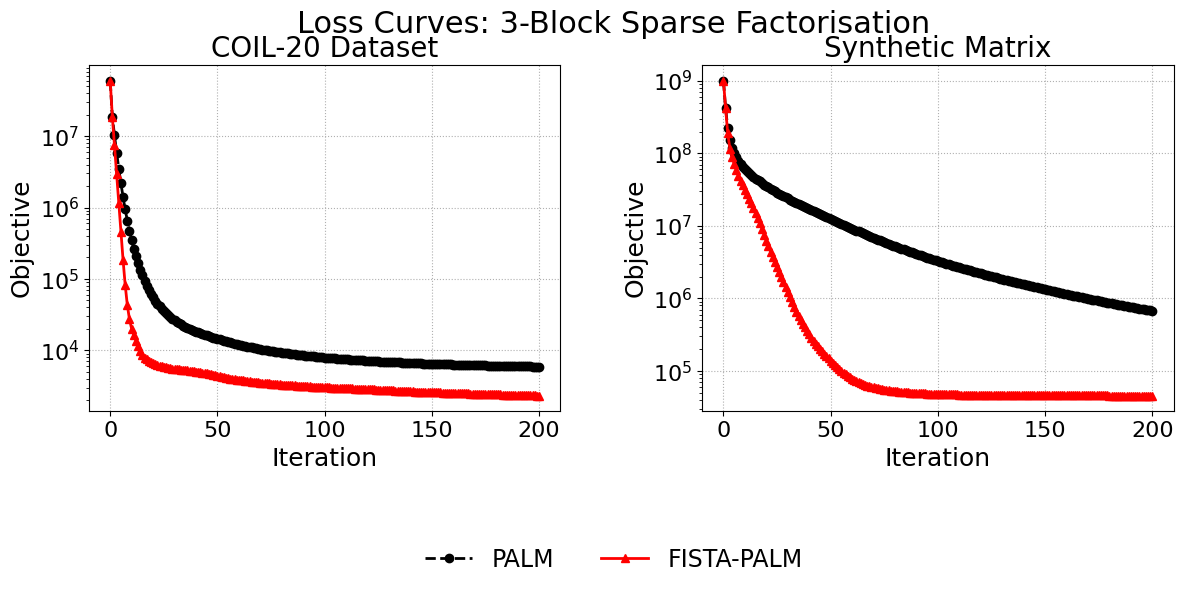

In [7]:
plot_three_block_dataset_comparison(
    histories,
    synthetic_histories,
    title="Loss Curves: 3-Block Sparse Factorisation",
    save_path=make_fig_path(ROOT, "coil_vs_synthetic_three_block", params),
)

## Observations

- FISTA-PALM decreases the objective faster than PALM on the COIL-20 three-block factorisation problem.

- The combined reconstruction grid shows that both methods recover the main object structure, but FISTA-PALM gives cleaner and more defined reconstructions under the same iteration budget.

- PALM produces blurrier reconstructions, suggesting that the additional middle factor $B$ makes the optimisation problem harder for the basic alternating scheme.

- The synthetic comparison shows the same trend: FISTA-PALM achieves faster objective reduction on both real COIL-20 data and a synthetic matrix with matching dimensions.

- Overall, this experiment shows that the acceleration benefit of FISTA-PALM carries over from two-block factorisation to the more complex three-block model $A \approx XBY^T$.